Implementing TunED as in the paper, checking for the driver variable between % of escape and shelter distance in the escape/homing period

This uses chatgpt generated code for tuned

In [14]:
%load_ext autoreload
from behave_analysis.utils.creating_directories import make_directory
from JR_test_scripts.escape.escape_utils import load, load_homing, compute_dist_shelt
from JR_test_scripts.escape.escape_tuning_funcs import tuning_method
from JR_test_scripts.escape.escape_data_loading_funcs import extract_homing_and_escape_periods

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic, ks_2samp
from scipy.ndimage import gaussian_filter1d

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
"""Load in all necessary data, need to create tuning curves that have the same number of bins for the two behavioral variables"""
from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip4_21mar
exp = JAL6_flip4_21mar

%autoreload 2
# 1. load in distance to shelter in escape/homing tuning curve
comp = 'bird_dist_shelter'
nickname = exp.nick_name + '_' + exp.experiment_date
exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + comp
dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/median/" + nickname)
saving_file = dump_path + exp_nickname + '_ProperTuning.npz'
data = np.load(saving_file)

# pull out the params
data_files = data.files
if 'params_real' in data_files:
    exp_params_real = data['params_real']
    exp_params_shifts = data['params_shifts']
else:
    exp_params_real = data["arr_12"]
    exp_params_shifts = data["arr_1"]

# create vector of which cells are sig to distance in exploration
# find sig. cells that have gaussian amplitude greater than 95th perc of linear shifts
exp_sig_cells = exp_params_real[:,:,0] > np.nanpercentile(exp_params_shifts[:,:,:,0], 95, axis = 0)

# 2. load in %escape in homing/escape tuning curve
comp = 'escape'
exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + comp
dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/median/" + nickname)
saving_file = dump_path + exp_nickname + '_ProperTuning.npz'
data = np.load(saving_file)

data_files = data.files
if 'params_real' in data_files:
    fr_full_esc = data["fr_full"]
    params_real = data['params_real']
    params_shifts = data['params_shifts']
else:
    fr_full_esc = data["arr_8"]
    params_real = data["arr_12"]
    params_shifts = data["arr_1"]

# create vector of which cells are sig to fraction of escape
# find sig. cells that have gaussian amplitude greater than 95th perc of linear shifts
sig_cells = params_real[:,:,0] > np.nanpercentile(params_shifts[:,:,:,0], 95, axis = 0)

# 3. load in neural data
session, frame_by_cluster_matrix, behave, y_pos, x_pos, bar, barflip, escape, outofshelter = load(exp)
ons, offs, homie = load_homing(session, len(behave))
fcm = gaussian_filter1d(frame_by_cluster_matrix, 2, axis = 0)

# 4. extract escape matrix with respect to 'escape'
comp = 'escape'
frac_escape, escape_matrix, cond, h_start = extract_homing_and_escape_periods(session, 
                                                                                fcm, 
                                                                                behave, 
                                                                                y_pos, x_pos, 
                                                                                bar, 
                                                                                barflip, 
                                                                                comp, 
                                                                                ons, offs, 
                                                                                no_stationary = False, 
                                                                                return_escape = False,
                                                                                zscore = False)

# initialize vars
bins_escape = int(np.amax(frac_escape)+1)
n_neur = frame_by_cluster_matrix.shape[1]
n_cond = len(np.unique(cond))

# 5. extract neural data with respect to 'distance to shelter'
comp = 'bird_dist_shelter'
full_bird_dist_shelt = compute_dist_shelt(x_pos, y_pos, cond=np.zeros_like(x_pos), session=session)
bin_size = np.amax(full_bird_dist_shelt)/(bins_escape)
shelt_dist, _, _, _ = extract_homing_and_escape_periods(session, 
                                                        fcm, 
                                                        behave, 
                                                        y_pos, x_pos, 
                                                        bar, 
                                                        barflip, 
                                                        comp, 
                                                        ons, offs, 
                                                        no_stationary = False, 
                                                        return_escape = False,
                                                        zscore = False,
                                                        bin_size = bin_size)

# initialize vars
bins_dist = int(np.amax(shelt_dist)+1)

# 6. recompute tuning curve for distance to shelter with the same number of bins as escape
y_fitted_full_dist, R_full_dist, fr_full_dist, params_full_dist, mat_full_cond_dist = tuning_method(shelt_dist, 
                                                                                                    escape_matrix, 
                                                                                                    cond, 
                                                                                                    h_start, 
                                                                                                    bins_escape, 
                                                                                                    n_cond,
                                                                                                    n_neur)


2025-02-19 10:57:10.428 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...


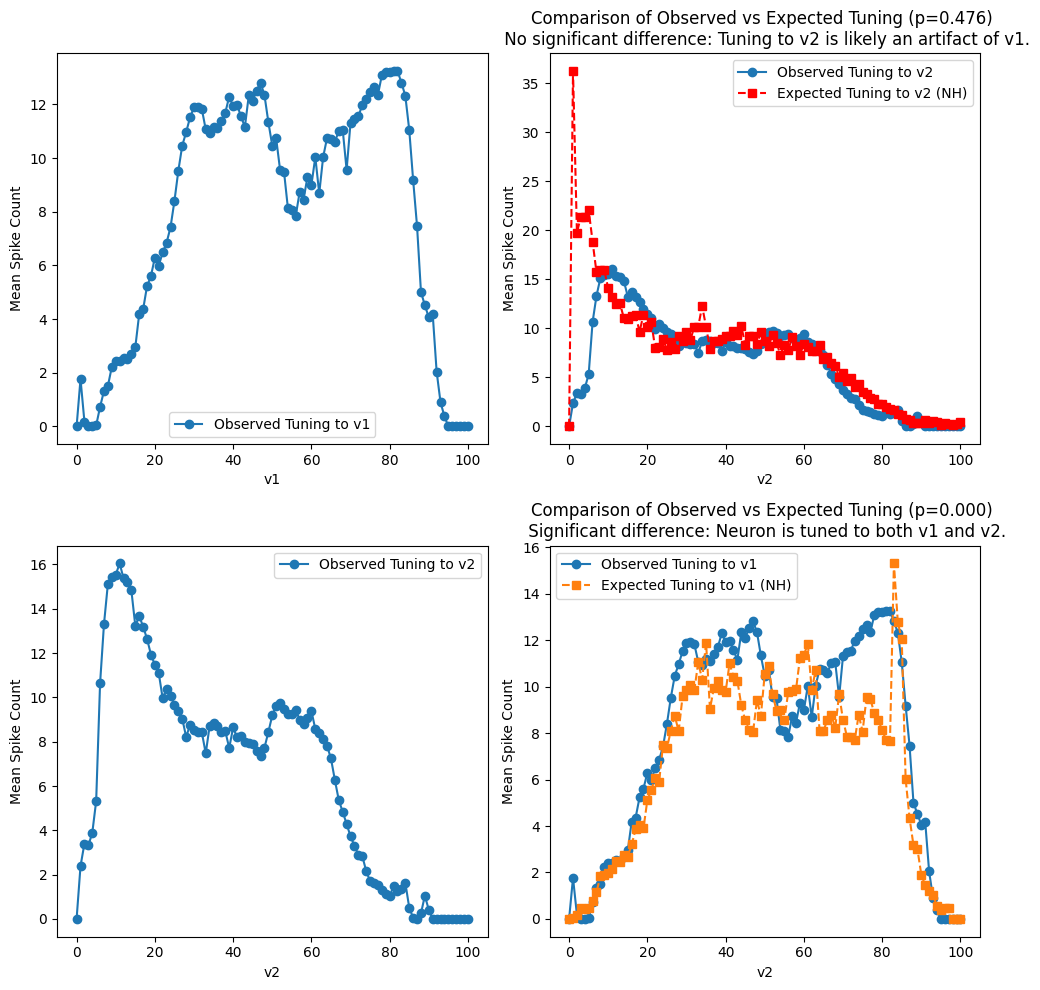

Text(0.5, 1.0, 'Estimated P(v1 | v2) using Discrete Bins')

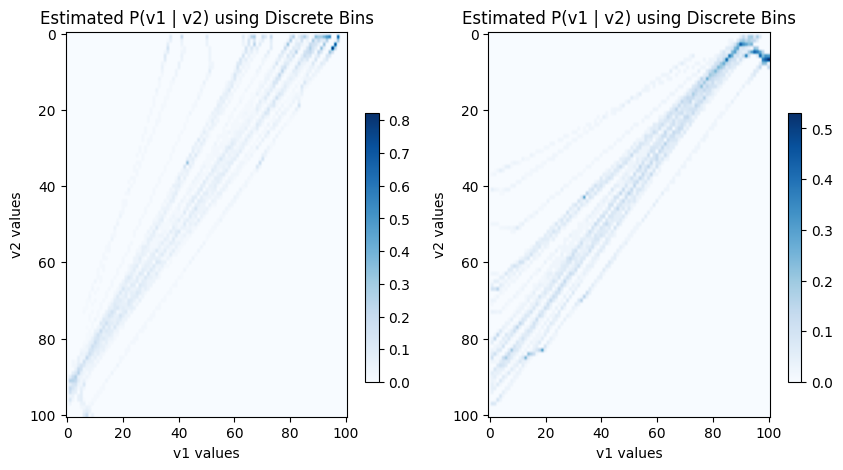

In [102]:
"""Test the code for TunED on real data"""

def estimate_p_v1_given_v2(v1, v2, bin_edges):

    # Compute joint histogram P(v1, v2)
    joint_hist, _, _ = np.histogram2d(v1, v2, bins=[bin_edges, bin_edges], density=True)

    # Compute marginal probability P(v2)
    p_v2, _ = np.histogram(v2, bins=bin_edges, density=True)

    # Compute conditional probability P(v1 | v2) (avoid division by zero)
    p_v1_given_v2 = (joint_hist.T / (p_v2 + 1e-8)).T  

    # set to zero where p_v2 is zero
    p_v1_given_v2[p_v2 == 0, :] = 0

    return p_v1_given_v2

def estimate_p_conditional_LF(v1, v2, bin_edges):

    # Compute joint histogram P(v1, v2)
    joint_prob, _, _ = np.histogram2d(v1, v2, bins=[bin_edges, bin_edges], density=True)

    # Compute marginal probability P(v2)
    Pv1 = np.sum(joint_prob, axis=0)
    Pv2 = np.sum(joint_prob, axis=1)

    # Compute conditional probability P(v1 | v2) (avoid division by zero)
    Pv2_v1 = joint_prob / (np.ones(len(Pv2)).reshape(-1, 1) * (Pv1 + 1e-8))
    Pv1_v2 = joint_prob.T / (np.ones(len(Pv1)).reshape(-1, 1) * (Pv2 + 1e-8))  # P(v1|v2)

    # set to zero where p_v2 is zero
    # Pv1_v2[Pv2 == 0, :] = 0
    # Pv2_v1[Pv1 == 0, :] = 0

    return Pv2_v1, Pv1_v2

def compute_expected_tuning(mu_v1, p_v1_given_v2):
    mu_NH_v2 = np.dot(p_v1_given_v2, mu_v1)  # Approximate integral as matrix multiplication
    return mu_NH_v2

# choose a cell to test
c = 0 # which condition do we want to look at
goodones = np.where(np.logical_and(exp_sig_cells[:,c], sig_cells[:,c]))[0]
idx = 4

# Step 1: Real Observed Tuning Curves
mu_v1 = fr_full_esc[c, goodones[idx],:]
mu_v2 = fr_full_dist[c, goodones[idx],:]

# Step 3: Estimate P(v1 | v2)

v1 = frac_escape[cond == c]
v2 = shelt_dist[cond == c]
bin_edges = np.arange(bins_escape + 1)

# ChatGPT method
# p_v1_given_v2 = estimate_p_v1_given_v2(v1, v2, bin_edges)
# p_v2_given_v1 = estimate_p_v1_given_v2(v2, v1, bin_edges)

# Laurence method
p_v1_given_v2, p_v2_given_v1 = estimate_p_conditional_LF(v1, v2, bin_edges)

# Step 4: Compute Expected Tuning Curve Under NH

mu_NH_v2 = compute_expected_tuning(mu_v1, p_v1_given_v2)
# mu_NH_v2[mu_v1 == 0] = 0
mu_NH_v1 = compute_expected_tuning(mu_v2, p_v2_given_v1)

# Step 5: Compare Actual vs Expected Tuning
ks_stat_v1, p_value_v1 = ks_2samp(mu_v2, mu_NH_v2)
ks_stat_v2, p_value_v2 = ks_2samp(mu_v1, mu_NH_v1)

# Plot Results v1
fig, axs = plt.subplots(2,2,figsize=(10,10))

axs[0,0].plot(bin_edges[:-1], mu_v1, label="Observed Tuning to v1", marker='o')
axs[0,0].set_xlabel("v1")
axs[0,0].set_ylabel("Mean Spike Count")
axs[0,0].legend()

axs[0,1].plot(bin_edges[:-1], mu_v2, label="Observed Tuning to v2", marker='o')
axs[0,1].plot(bin_edges[:-1], mu_NH_v2, label="Expected Tuning to v2 (NH)", linestyle='--', marker='s', color='r')
axs[0,1].set_xlabel("v2")
axs[0,1].set_ylabel("Mean Spike Count")
axs[0,1].legend()

if p_value_v1 < 0.05:
    axs[0,1].set_title(f"Comparison of Observed vs Expected Tuning (p={p_value_v1:.3f}) \n Significant difference: Neuron is tuned to both v1 and v2.")
else:
    axs[0,1].set_title(f"Comparison of Observed vs Expected Tuning (p={p_value_v1:.3f}) \n No significant difference: Tuning to v2 is likely an artifact of v1.")

# Plot Results v2
axs[1,0].plot(bin_edges[:-1], mu_v2, label="Observed Tuning to v2", marker='o')
axs[1,0].set_xlabel("v2")
axs[1,0].set_ylabel("Mean Spike Count")
axs[1,0].legend()

axs[1,1].plot(bin_edges[:-1], mu_v1, label="Observed Tuning to v1", marker='o')
axs[1,1].plot(bin_edges[:-1], mu_NH_v1, label="Expected Tuning to v1 (NH)", linestyle='--', marker='s')
axs[1,1].set_xlabel("v2")
axs[1,1].set_ylabel("Mean Spike Count")
axs[1,1].legend()

if p_value_v2 < 0.05:
    axs[1,1].set_title(f"Comparison of Observed vs Expected Tuning (p={p_value_v2:.3f}) \n Significant difference: Neuron is tuned to both v1 and v2.")
else:
    axs[1,1].set_title(f"Comparison of Observed vs Expected Tuning (p={p_value_v2:.3f}) \n No significant difference: Tuning to v1 is likely an artifact of v2.")

plt.tight_layout()
plt.show()

# Plot the conditional probabilities of the behaviors
fig, axs = plt.subplots(1,2,figsize=(10,5))

cb = axs[0].imshow(p_v1_given_v2, cmap="Blues", aspect="auto")
axs[0].set_xlabel("v1 values")
axs[0].set_ylabel("v2 values")
fig.colorbar(cb, ax=axs[0], location='right', anchor=(0, 0.3), shrink=0.7)
axs[0].set_title("Estimated P(v1 | v2) using Discrete Bins")

cb = axs[1].imshow(p_v2_given_v1, cmap="Blues", aspect="auto")
axs[1].set_xlabel("v1 values")
axs[1].set_ylabel("v2 values")
fig.colorbar(cb, ax=axs[1], location='right', anchor=(0, 0.3), shrink=0.7)
axs[1].set_title("Estimated P(v1 | v2) using Discrete Bins")

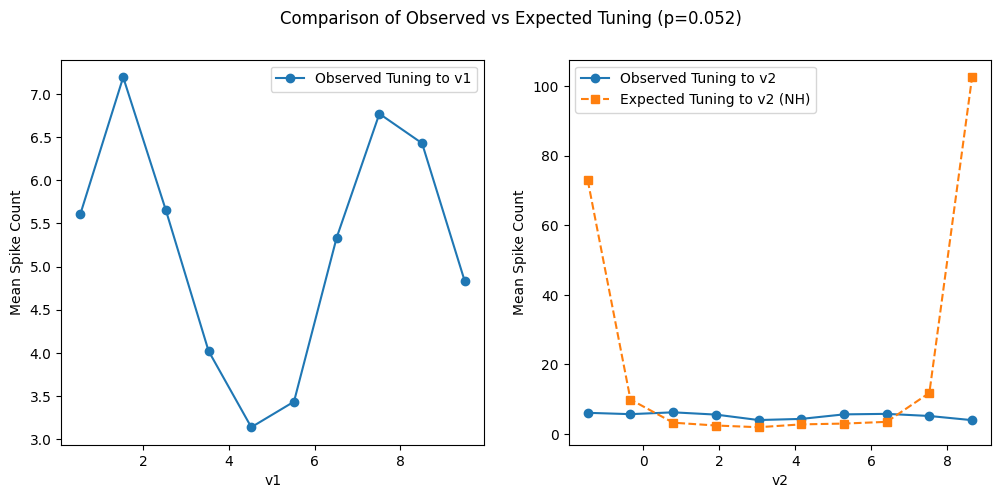

No significant difference: Tuning to v2 is likely an artifact of v1.


In [13]:
"""Toy example with toy data"""

# Step 1: Simulate Data
np.random.seed(42)
n_samples = 1000

# Generate correlated v1 and v2
v1 = np.random.uniform(0, 10, n_samples)  # Stimulus variable 1
v2 = v1 * 0.7 + np.random.normal(0, 1, n_samples)  # Correlated variable 2

# Generate spike counts based on v1
true_tuning_curve = lambda x: 5 + 2 * np.sin(x)  # True tuning function
spike_counts = np.random.poisson(true_tuning_curve(v1))  # Poisson spike generation

# Step 2: Compute Observed Tuning Curves
def compute_tuning_curve(variable, spike_counts, bins=10):
    bin_means, bin_edges, _ = binned_statistic(variable, spike_counts, statistic='mean', bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    return bin_centers, bin_means

v1_centers, mu_v1 = compute_tuning_curve(v1, spike_counts)
v2_centers, mu_v2 = compute_tuning_curve(v2, spike_counts)

# Step 3: Estimate P(v1 | v2)
def estimate_p_v1_given_v2(v1, v2, bins=10):
    joint_hist, v1_edges, v2_edges = np.histogram2d(v1, v2, bins=bins, density=True)
    p_v2 = np.histogram(v2, bins=v2_edges, density=True)[0]
    p_v1_given_v2 = (joint_hist.T / (p_v2 + 1e-8)).T  # Avoid division by zero
    v1_centers = (v1_edges[:-1] + v1_edges[1:]) / 2
    v2_centers = (v2_edges[:-1] + v2_edges[1:]) / 2
    return v1_centers, v2_centers, p_v1_given_v2

v1_centers, v2_centers, p_v1_given_v2 = estimate_p_v1_given_v2(v1, v2)

# Step 4: Compute Expected Tuning Curve Under NH
def compute_expected_tuning(mu_v1, p_v1_given_v2):
    mu_NH_v2 = np.dot(p_v1_given_v2, mu_v1)  # Approximate integral as matrix multiplication
    return mu_NH_v2

mu_NH_v2 = compute_expected_tuning(mu_v1, p_v1_given_v2)

# Step 5: Compare Actual vs Expected Tuning
ks_stat, p_value = ks_2samp(mu_v2, mu_NH_v2)

# Plot Results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(v1_centers, mu_v1, label="Observed Tuning to v1", marker='o')
plt.xlabel("v1")
plt.ylabel("Mean Spike Count")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(v2_centers, mu_v2, label="Observed Tuning to v2", marker='o')
plt.plot(v2_centers, mu_NH_v2, label="Expected Tuning to v2 (NH)", linestyle='--', marker='s')
plt.xlabel("v2")
plt.ylabel("Mean Spike Count")
plt.legend()

plt.suptitle(f"Comparison of Observed vs Expected Tuning (p={p_value:.3f})")
plt.show()

# Step 6: Conclusion
if p_value < 0.05:
    print("Significant difference: Neuron is tuned to both v1 and v2.")
else:
    print("No significant difference: Tuning to v2 is likely an artifact of v1.")